Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded successfully
Model input shape : (None, 224, 224, 3)
Model output shape: (None, 4)
Class order used by model:
['glioma', 'meningioma', 'notumor', 'pituitary']

Upload one MRI image:


Saving b740ddcd0e96cb1928682b04e83d84_big_gallery.jpeg to b740ddcd0e96cb1928682b04e83d84_big_gallery.jpeg
Uploaded image: b740ddcd0e96cb1928682b04e83d84_big_gallery.jpeg

Final Prediction
Predicted Class: notumor
Confidence: 99.62 %

All Class Probabilities:
glioma: 0.0%
meningioma: 0.38%
notumor: 99.62%
pituitary: 0.0%


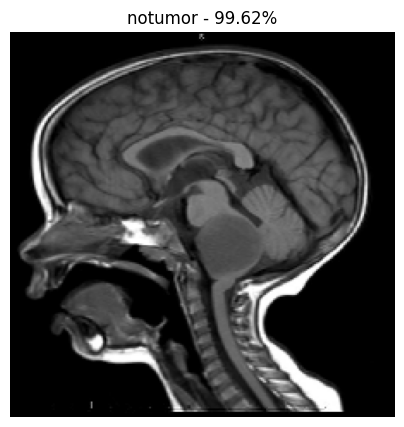

In [13]:
from google.colab import drive, files
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import load_img, img_to_array

# =====================================================
# 1. Mount Google Drive
# =====================================================
drive.mount("/content/drive")

# =====================================================
# 2. Model and class-index paths
# Use the same saved model from your notebook
# =====================================================

MODEL_PATH = "/content/drive/MyDrive/bt_detection/fixed_model_output/brain_tumor_vgg16_best.h5"
CLASS_INDICES_PATH = "/content/drive/MyDrive/bt_detection/fixed_model_output/class_indices.json"

# If you want to use .keras instead, use this:
# MODEL_PATH = "/content/drive/MyDrive/bt_detection/fixed_model_output/brain_tumor_vgg16_best.keras"

# =====================================================
# 3. Load model
# =====================================================
model = keras.models.load_model(MODEL_PATH, compile=False)

print("Model loaded successfully")
print("Model input shape :", model.input_shape)
print("Model output shape:", model.output_shape)

# =====================================================
# 4. Load class names exactly from training
# Do not manually type class names if class_indices.json exists
# =====================================================
with open(CLASS_INDICES_PATH, "r") as f:
    class_indices = json.load(f)

idx_to_class = {int(v): k for k, v in class_indices.items()}

class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print("Class order used by model:")
print(class_names)

# Expected:
# ['glioma', 'meningioma', 'notumor', 'pituitary']

# =====================================================
# 5. Set image size
# Your model was trained using 224x224
# =====================================================
IMG_SIZE = (224, 224)

# =====================================================
# 6. Upload one image
# =====================================================
print("\nUpload one MRI image:")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)

# =====================================================
# 7. Load image
# =====================================================
img = load_img(image_path, target_size=IMG_SIZE, color_mode="rgb")

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# =====================================================
# 8. IMPORTANT FIX
# Use VGG16 preprocessing because your model was trained with it.
# Do NOT use img_array / 255.0
# =====================================================
img_array = keras.applications.vgg16.preprocess_input(img_array)

# =====================================================
# 9. Predict
# =====================================================
pred_probs = model.predict(img_array, verbose=0)[0]

pred_index = int(np.argmax(pred_probs))
predicted_class = idx_to_class[pred_index]
confidence = float(pred_probs[pred_index])

# =====================================================
# 10. Show result
# =====================================================
print("\nFinal Prediction")
print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence * 100, 2), "%")

print("\nAll Class Probabilities:")
for i, prob in enumerate(pred_probs):
    print(f"{idx_to_class[i]}: {round(float(prob) * 100, 2)}%")

plt.figure(figsize=(5, 5))
plt.imshow(load_img(image_path, target_size=IMG_SIZE))
plt.axis("off")
plt.title(f"{predicted_class} - {round(confidence * 100, 2)}%")
plt.show()